# Download OW Faults from a specific fault set via DSIS

This notebook provides a simple workflow for sending a request to DSIS using the `dsis-client` library developed by Equinor.

The following steps are covered:

1. Authenticate to DSIS using an `.env_dsis` file with the required configuration and credentials.
2. Construct and execute a query requesting faults belonging to a specific project.
3. Visualize the results returned by the query.

For more information about the required content of the `.env_dsis` file, please contact the SDD-SID team, or the DSIS team in Equinor.

In [ ]:
%matplotlib inline
from dotenv import load_dotenv
import os
from typing import Any
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import json
import inspect
import sys
from collections import defaultdict
from typing import Iterable
import inspect
from dsis_client import DSISClient, DSISConfig, QueryBuilder, Environment


In [2]:
load_dotenv(".env_dsis")

True

In [3]:
config = DSISConfig(
    environment=Environment.PROD,
    tenant_id=os.getenv("tenant_id"),
    client_id=os.getenv("client_id"),
    client_secret=os.getenv("client_secret"),
    access_app_id=os.getenv("resource_id"),
    dsis_username=os.getenv("dsis_function_key"),
    dsis_password=os.getenv("dsis_password"),
    subscription_key_dsauth=os.getenv("subscription_key_dsauth"),
    subscription_key_dsdata=os.getenv("subscription_key_dsdata"),
    dsis_site=os.getenv("dsis_site"),
)

In [4]:
dsis_client = DSISClient(config)
if dsis_client.test_connection():
    print("✓ Connected to DSIS API")

✓ Connected to DSIS API


In [5]:
MODEL_NAME = "OW5000"
MODEL_VERSION = "5000107"
DISTRICT = "BG4FROST"
PROJECT = "VOLVE_PUBLIC"

In [6]:
# Helper function which might be incorporated in the dsis-client library in the future


def build_district_id(database: str, *, model_name: str) -> str:
    """Build DSIS district_id from database name.

    DSIS uses different district-id conventions for different models.

    Examples:
    - OpenWorksCommonModel: OpenWorksCommonModel_OW_<DB>-OW_<DB>
    - OpenWorks native models (e.g., OW5000): OpenWorks_OW_<DB>_SingleSource-OW_<DB>
    """
    if model_name == "OpenWorksCommonModel":
        return f"OpenWorksCommonModel_OW_{database}-OW_{database}"
    return f"OpenWorks_OW_{database}_SingleSource-OW_{database}"

qkw: dict = {"district_id": build_district_id(DISTRICT, model_name=MODEL_NAME), "project": PROJECT}
if "model_name" in inspect.signature(QueryBuilder).parameters:
    qkw["model_name"] = MODEL_NAME

In [7]:
qkw

{'district_id': 'OpenWorks_OW_BG4FROST_SingleSource-OW_BG4FROST',
 'project': 'VOLVE_PUBLIC',
 'model_name': 'OW5000'}

In [ ]:
def fetch_segments(client, qkw: dict) -> list[dict]:
    """Return all FaultSegment records that have values (x/y coordinates). FaultSegment is the DSIS schema which represents a single segment of a fault, with x/y coordinates stored in the "values" property.
    In some cases there may be FaultSegment records with no values (i.e., no coordinates) - these are filtered out. In other projects fault segments may be stored using a different schema, so this function 
    may need to be modified accordingly."""
    return [
        seg
        for seg in client.execute_query(QueryBuilder(**qkw).schema("FaultSegment"), timeout=250)
        if seg.get("values")
    ]

def plot_fault_map(segments: Iterable[dict]) -> None:
    """Plot all faults as 2-D plan-view polylines, one colour per fault_plane_id."""
    by_plane: dict = defaultdict(list)
    for seg in segments:
        by_plane[seg["fault_plane_id"]].append(seg)

    if not by_plane:
        print("No segments to plot.")
        return

    plane_ids = list(by_plane.keys())
    cmap = plt.colormaps["tab20"]
    colours = [cmap(i % 20) for i in range(len(plane_ids))]

    fig, ax = plt.subplots(figsize=(10, 10))

    for colour, pid in zip(colours, plane_ids):
        for seg in by_plane[pid]:
            vals = seg["values"]
            x = [float(v) for v in vals["x"]]
            y = [float(v) for v in vals["y"]]
            ax.plot(x, y, color=colour, linewidth=1.0)

    n = len(plane_ids)
    ax.set_title(f"{PROJECT} — {n} fault{'s' if n != 1 else ''}")
    ax.set_aspect("equal")
    ax.grid(True, linewidth=0.4)
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    plt.xticks(rotation=-70)
    plt.tight_layout()
    plt.show()


Fetch fault names

In [22]:
query = (
    QueryBuilder(
        model_name=MODEL_NAME,
        model_version=MODEL_VERSION,
        district_id=build_district_id(DISTRICT, model_name=MODEL_NAME),
        project=PROJECT,
    )
    .schema("FaultSegment")
)

Fetching FaultSegments...
  1286 segments across 65 faults


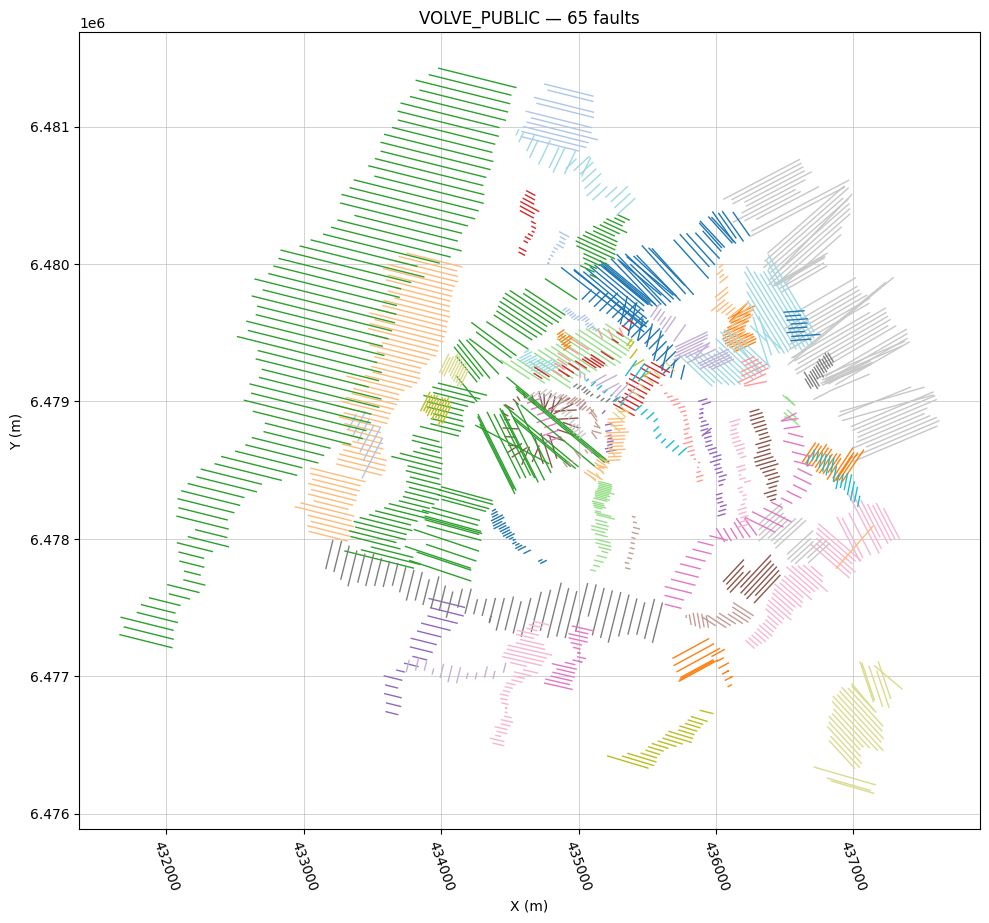

In [ ]:
print("Fetching FaultSegments...")
segments = fetch_segments(dsis_client, qkw)
n_faults = len({s["fault_plane_id"] for s in segments})
print(f"  {len(segments)} segments across {n_faults} faults")

# Print z unit and domain per fault_plane_id
by_plane: dict = defaultdict(list)
for seg in segments:
    by_plane[seg["fault_plane_id"]].append(seg)

print(f"\n{'fault_plane_id':<20} {'z_unit':<12} {'z_domain'}")
print("-" * 46)
for pid, segs in sorted(by_plane.items()):
    first = segs[0]
    z_unit = first.get("values_dsdsunit", "?")
    z_domain = (first.get("z_domain") or "UNKNOWN").upper()
    print(f"{pid:<20} {z_unit:<12} {z_domain}")

plot_fault_map(segments)
